In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
DATA_PATH = "../data/mdm2_data_files/big_table_weather_rain_clusters_safety.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print("Sensors:", df["sensor_id"].nunique())

(379477, 20)
Sensors: 46


In [3]:
df["active"] = df["ped"] + df["cyc"]

print(df["active"].describe())

count    379477.000000
mean        113.460310
std         205.034292
min           0.000000
25%           4.000000
50%          35.000000
75%         129.000000
max        5267.000000
Name: active, dtype: float64


In [4]:
cols_needed = [
    "active",
    "cluster_geo",
    "hour",
    "dow",
    "month",
    "temp_c",
    "wind_ms",
    "rain_mm",
    "Dark",
    "safety_scaled",
    "sensor_id"
]

df = df.dropna(subset=cols_needed)

print("Rows remaining:", len(df))

Rows remaining: 378005


In [5]:
formula = """
active ~
C(cluster_geo)
+ C(hour)
+ C(dow)
+ C(month)
+ temp_c
+ wind_ms
+ rain_mm
+ Dark
+ safety_scaled
+ Dark:C(cluster_geo)
+ Dark:safety_scaled
"""

In [6]:
print("Fitting Active Travel GLM...\n")

model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.NegativeBinomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["sensor_id"]}
)

print(model.summary())

Fitting Active Travel GLM...

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:               378005
Model:                            GLM   Df Residuals:                   377954
Model Family:        NegativeBinomial   Df Model:                           50
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.9500e+06
Date:                Thu, 05 Mar 2026   Deviance:                   8.1220e+05
Time:                        13:50:23   Pearson chi2:                 1.23e+06
No. Iterations:                    22   Pseudo R-squ. (CS):             0.6841
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [7]:
dispersion = model.pearson_chi2 / model.df_resid
print("Dispersion:", dispersion)

Dispersion: 3.2449074027601923


Darkness effect (% change):
{0: -12.090797513146912, 1: 37.568423829872735, 2: -23.13658666085001}


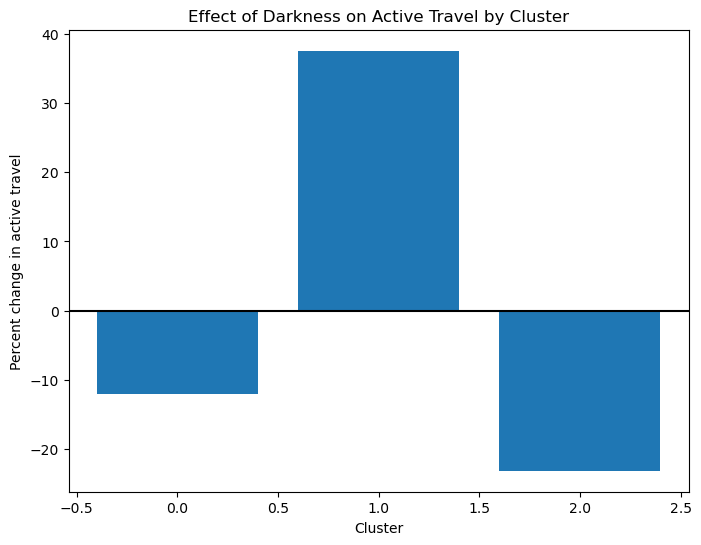

In [8]:
params = model.params

beta_dark = params["Dark"]
beta_c1 = params.get("Dark:C(cluster_geo)[T.1]",0)
beta_c2 = params.get("Dark:C(cluster_geo)[T.2]",0)

effects = {
    0: beta_dark,
    1: beta_dark + beta_c1,
    2: beta_dark + beta_c2
}

pct = {k:(np.exp(v)-1)*100 for k,v in effects.items()}

print("Darkness effect (% change):")
print(pct)

plt.figure(figsize=(8,6))
plt.bar(pct.keys(), pct.values())
plt.axhline(0,color="black")
plt.xlabel("Cluster")
plt.ylabel("Percent change in active travel")
plt.title("Effect of Darkness on Active Travel by Cluster")
plt.show()

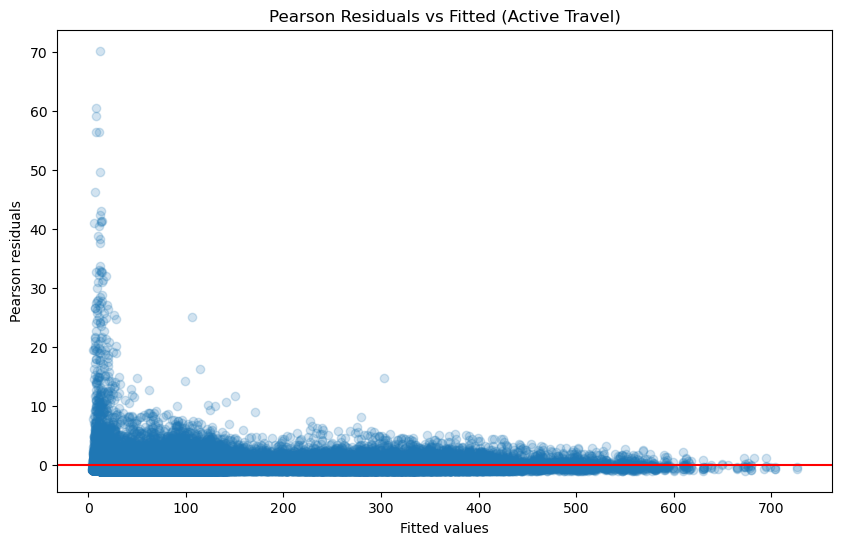

In [10]:
resid = model.resid_pearson
fitted = model.fittedvalues

idx = np.random.choice(len(resid),50000,replace=False)

plt.figure(figsize=(10,6))

plt.scatter(fitted.iloc[idx],resid.iloc[idx],alpha=0.2)

plt.axhline(0,color="red")

plt.xlabel("Fitted values")
plt.ylabel("Pearson residuals")

plt.title("Pearson Residuals vs Fitted (Active Travel)")

plt.show()

<Figure size 800x600 with 0 Axes>

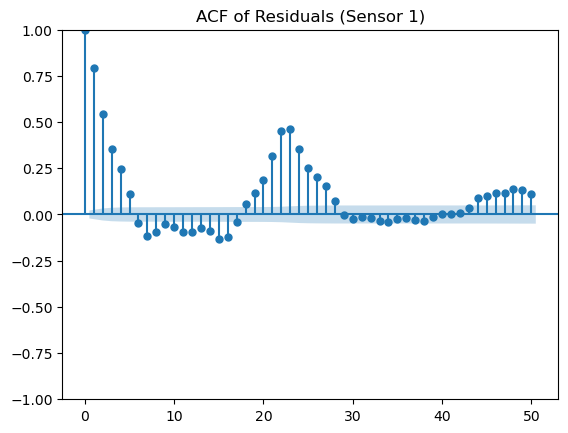

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

# choose an example sensor
sensor = df["sensor_id"].iloc[0]

sub = df[df["sensor_id"] == sensor].sort_values("datetime")

residuals = model.resid_pearson.loc[sub.index]

plt.figure(figsize=(8,6))

plot_acf(residuals, lags=50)

plt.title(f"ACF of Residuals (Sensor {sensor})")

plt.show()